# Layer 2 New — Hybrid Road Condition Score

Builds a 3-class paved road condition label (`good` / `med` / `low`) combining two complementary signals:

- **Physics-motivated score (§4–6)**: interpretable combination of S1 backscatter smoothness, temporal stability, S2 bare-soil intrusion, and vegetation encroachment — grounded in remote sensing theory.
- **Supervised Random Forest (§7)**: trained on 2,096 visually-labelled roads from Mapillary imagery, with `class_weight='balanced'` to handle the 77/19/4 label skew and `pred_confidence` as sample weights.
- **Hybrid blend (§9)**: `α × supervised_proba + (1−α) × physics_proba`. The physics score acts as a theoretically-grounded prior; the supervised model learns the class boundaries from ground truth.

Out-of-fold cross-validation (§10) evaluates all three methods against the manual labels without data leakage.

## 0) Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)

def find_repo_root(start=None, repo_name='Sentinel-FYP'):
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if candidate.name == repo_name:
            return candidate
    raise FileNotFoundError(f'Could not find repo root named {repo_name!r}')

ROOT = find_repo_root()
DATA_DIR = ROOT / 'data'
S1_DIR = DATA_DIR / 'ghana_parquet_s1'

pbf_candidates = sorted(DATA_DIR.glob('*.osm.pbf'))
PBF_PATH = pbf_candidates[-1] if pbf_candidates else None

print('Repo root:', ROOT)
print('S1 dir exists:', S1_DIR.exists())
print('PBF:', PBF_PATH.name if PBF_PATH else '(not found)')

Repo root: /Users/miranda/Documents/GitHub/Sentinel-FYP
S1 dir exists: True
PBF: ghana-260415.osm.pbf


## 1) Identify paved roads from OSM

Layer 2 only scores paved roads — Layer 1's policy rule already maps unpaved → high risk. Uses OSM surface tags as the paved label source. In production, swap this for Layer 1 predictions on all 326k roads.

In [2]:
from pyrosm import OSM

osm = OSM(str(PBF_PATH))
roads_osm = osm.get_network(network_type='driving').copy()

roads_osm['osm_id'] = roads_osm['id'].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()
roads_osm['surface_clean'] = roads_osm['surface'].astype(str).str.lower().str.strip()
roads_osm['road_name_clean'] = roads_osm.get('name', pd.Series(index=roads_osm.index, dtype='object')).astype(str).str.strip()
roads_osm.loc[roads_osm['road_name_clean'].isin(['', 'nan', 'None']), 'road_name_clean'] = np.nan

focus_classes = ['residential', 'service', 'trunk', 'primary', 'secondary', 'tertiary', 'unclassified']
roads_osm = roads_osm[roads_osm['highway'].isin(focus_classes)].copy()

paved_vals = {'paved', 'asphalt', 'concrete', 'paving_stones', 'concrete:plates', 'sett', 'cobblestone', 'metal', 'bricks', 'cement', 'chipseal'}
unpaved_vals = {'unpaved', 'ground', 'dirt', 'earth', 'gravel', 'fine_gravel', 'sand', 'mud', 'grass', 'compacted', 'pebblestone', 'soil'}

roads_osm['layer1_label'] = np.where(
    roads_osm['surface_clean'].isin(paved_vals), 'paved',
    np.where(roads_osm['surface_clean'].isin(unpaved_vals), 'unpaved', None)
)

# Name propagation
name_known = roads_osm.dropna(subset=['road_name_clean', 'layer1_label']).copy()
name_stats = (
    name_known.groupby('road_name_clean')['layer1_label']
    .agg(lambda s: sorted(set(s.dropna().tolist())))
    .to_frame('classes')
)
name_stats['n_classes'] = name_stats['classes'].apply(len)
name_stats['inferred_label'] = np.where(
    name_stats['n_classes'] == 1,
    name_stats['classes'].apply(lambda x: x[0]),
    np.nan,
)
name_to_label = name_stats['inferred_label'].dropna()

fill_mask = roads_osm['layer1_label'].isna() & roads_osm['road_name_clean'].notna()
roads_osm.loc[fill_mask, 'layer1_label'] = roads_osm.loc[fill_mask, 'road_name_clean'].map(name_to_label)

paved_ids = set(roads_osm.loc[roads_osm['layer1_label'] == 'paved', 'osm_id'].astype(str))
print(f'Paved roads identified: {len(paved_ids)}')

/opt/anaconda3/envs/sentinel/lib/python3.11/site-packages/pyrosm/networks.py:37: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  edges, nodes = prepare_geodataframe(


Paved roads identified: 14366


## 2) Load multi-year S1 + S2 features (paved only)

Filters to paved roads at load time to avoid the OOM seen in `layer1_s1.ipynb`.

In [3]:
idx_cols = ['NDVI', 'NDMI', 'NDBI', 'NDWI', 'BSI']
s1_cols = ['s1_vv_mean', 's1_vh_mean', 's1_vv_minus_vh_mean', 's1_vv_std', 's1_vh_std', 's1_vv_minus_vh_std']
YEARS = [2017, 2018, 2019, 2020, 2021, 2022, 2023]

def read_year(year):
    year_dir = S1_DIR / f'year={year}'
    if not year_dir.exists():
        raise FileNotFoundError(f'Missing: {year_dir}')
    files = sorted(year_dir.glob('*.parquet'))
    frames = [pd.read_parquet(f) for f in files]
    out = pd.concat(frames, ignore_index=True)
    out['year'] = year
    return out

multi_frames = []
for y in YEARS:
    yf = read_year(y)
    yf['osm_id'] = yf['osm_id'].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()
    yf = yf[yf['osm_id'].isin(paved_ids)]
    for c in idx_cols + s1_cols:
        if c in yf.columns:
            yf[c] = pd.to_numeric(yf[c], errors='coerce')
    present_s1 = [c for c in s1_cols if c in yf.columns]
    multi_frames.append(yf[['osm_id', 'quarter', 'year', *idx_cols, *present_s1]])

paved_long = pd.concat(multi_frames, ignore_index=True)
s1_cols_present = [c for c in s1_cols if c in paved_long.columns]

print('Paved-only rows:', len(paved_long))
print('Paved unique roads:', paved_long['osm_id'].nunique())
print('Years:', sorted(paved_long['year'].unique().tolist()))
print('S1 cols:', s1_cols_present)

Paved-only rows: 399924
Paved unique roads: 14283
Years: [2017, 2018, 2019, 2020, 2021, 2022, 2023]
S1 cols: ['s1_vv_mean', 's1_vh_mean', 's1_vv_minus_vh_mean', 's1_vv_std', 's1_vh_std', 's1_vv_minus_vh_std']


## 3) Engineer per-road condition features

Per-road aggregates across the full 2017–2023 window:
- **S1 smoothness proxies**: VV mean (low = smoother), VV temporal std (high = unstable), VH mean, VV-VH ratio
- **S2 intrusion proxies**: BSI mean (bare soil on/near road), NDVI mean and seasonal amplitude (vegetation encroachment)
- **Trend slopes** over years: ΔVV/year, ΔBSI/year, ΔNDVI/year — positive slopes indicate deterioration

In [10]:
# Per-road static aggregates across all quarters+years
agg_kwargs = {
    'vv_mean':       ('s1_vv_mean',           'mean'),
    'vv_std_temp':   ('s1_vv_mean',           'std'),
    'vh_mean':       ('s1_vh_mean',           'mean'),
    'vvvh_mean':     ('s1_vv_minus_vh_mean',  'mean'),
    'vvvh_std':      ('s1_vv_minus_vh_mean',  'std'),
    'ndvi_mean':     ('NDVI',                  'mean'),
    'ndvi_std':      ('NDVI',                  'std'),
    'ndbi_mean':     ('NDBI',                  'mean'),
    'bsi_mean':      ('BSI',                   'mean'),
    'bsi_std':       ('BSI',                   'std'),
    'ndmi_mean':     ('NDMI',                  'mean'),
}
road_feats = paved_long.groupby('osm_id', as_index=False).agg(**agg_kwargs)

# Per-road temporal slope (linear fit across years)
def slope_per_year(df_long, col, out_name):
    yearly = df_long.groupby(['osm_id', 'year'], as_index=False)[col].mean()
    rows = []
    for oid, g in yearly.groupby('osm_id'):
        if len(g) >= 3 and g[col].notna().sum() >= 3:
            x = g['year'].values.astype(float)
            y = g[col].values.astype(float)
            mask = ~np.isnan(y)
            slope = float(np.polyfit(x[mask], y[mask], 1)[0]) if mask.sum() >= 3 else np.nan
        else:
            slope = np.nan
        rows.append({'osm_id': oid, out_name: slope})
    return pd.DataFrame(rows)

vv_slope = slope_per_year(paved_long, 's1_vv_mean', 'vv_slope_year')
bsi_slope = slope_per_year(paved_long, 'BSI', 'bsi_slope_year')
ndvi_slope = slope_per_year(paved_long, 'NDVI', 'ndvi_slope_year')

road_feats = road_feats.merge(vv_slope, on='osm_id', how='left')
road_feats = road_feats.merge(bsi_slope, on='osm_id', how='left')
road_feats = road_feats.merge(ndvi_slope, on='osm_id', how='left')

# Seasonal NDVI amplitude
quarter_map = {'Q1': 1, 'Q2': 2, 'Q3': 3, 'Q4': 4}
paved_long['q_num'] = paved_long['quarter'].map(quarter_map)
seasonal = paved_long.groupby(['osm_id', 'q_num'], as_index=False)['NDVI'].mean()
seasonal_p = seasonal.pivot(index='osm_id', columns='q_num', values='NDVI').reset_index()
for q in [1, 2, 3, 4]:
    if q not in seasonal_p.columns:
        seasonal_p[q] = np.nan
seasonal_p['ndvi_seasonal_amp'] = seasonal_p[[1, 2, 3, 4]].max(axis=1) - seasonal_p[[1, 2, 3, 4]].min(axis=1)
road_feats = road_feats.merge(seasonal_p[['osm_id', 'ndvi_seasonal_amp']], on='osm_id', how='left')

# Fill missing with median
num_cols = [c for c in road_feats.columns if c != 'osm_id']
road_feats[num_cols] = road_feats[num_cols].fillna(road_feats[num_cols].median())

print('Road feature table:', road_feats.shape)
road_feats.head()

Road feature table: (14283, 16)


,osm_id,vv_mean,vv_std_temp,vh_mean,vvvh_mean,vvvh_std,ndvi_mean,ndvi_std,ndbi_mean,bsi_mean,bsi_std,ndmi_mean,vv_slope_year,bsi_slope_year,ndvi_slope_year,ndvi_seasonal_amp
0,1000780304,-8.533243,2.126240,-14.967101,6.433859,1.211630,0.045184,0.046983,0.167395,0.164470,0.069221,-0.167395,0.723593,-0.005423,-0.022523,0.055078
1,1000780305,-7.746213,2.439916,-15.051881,7.305669,2.683590,0.050361,0.047532,0.149045,0.152611,0.065251,-0.149045,-0.843880,-0.003735,-0.022660,0.057528
2,1000780306,-9.595445,1.942771,-15.984284,6.388839,1.156873,0.045943,0.050104,0.168740,0.164124,0.069431,-0.168740,0.586008,-0.003929,-0.024658,0.058221
3,1000780307,-8.491406,3.489234,-15.243577,6.752171,0.815337,0.038495,0.037250,0.166033,0.162685,0.071489,-0.166033,1.334483,-0.008827,-0.013761,0.038016
4,1001362632,-9.619407,0.280117,-16.046886,6.427479,0.439891,0.321336,0.127385,0.007728,0.046376,0.065615,-0.007728,-0.011623,-0.012849,-0.018744,0.237596


## 4) Physics-motivated condition score (Option 1)

Higher score = better condition. Robust z-scores (median/MAD) keep outliers from dominating. Weights are deliberate priors — VV smoothness is the strongest single signal, temporal stability next, surface intrusion features as supporting evidence.

count    14283.000
mean        -0.440
std          1.948
min        -20.324
25%         -1.348
50%         -0.128
75%          0.797
max          4.590
Name: condition_score, dtype: float64


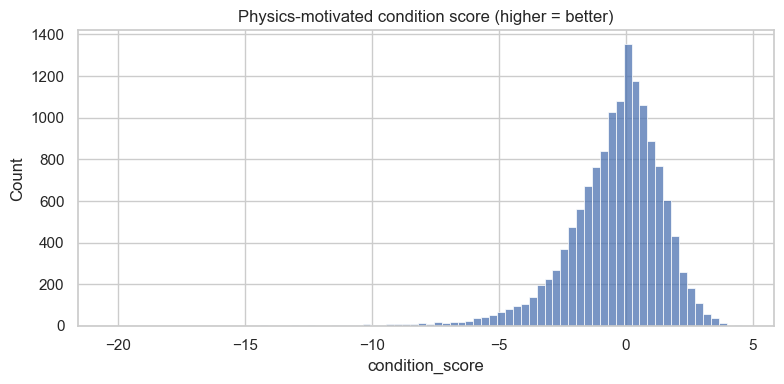

In [11]:
def z_robust(s):
    med = s.median()
    mad = (s - med).abs().median() or 1.0
    return (s - med) / (1.4826 * mad)

road_feats['score_smoothness']   = z_robust(-road_feats['vv_mean'])         # low VV  -> smooth -> good
road_feats['score_stability']    = z_robust(-road_feats['vv_std_temp'])     # low VV temporal std -> stable
road_feats['score_no_intrusion'] = z_robust(-road_feats['bsi_mean'])        # low BSI -> no bare-soil intrusion
road_feats['score_low_veg']      = z_robust(-road_feats['ndvi_seasonal_amp'])  # low amp -> no veg encroachment

road_feats['condition_score'] = (
    1.0 * road_feats['score_smoothness'] +
    0.8 * road_feats['score_stability'] +
    0.5 * road_feats['score_no_intrusion'] +
    0.3 * road_feats['score_low_veg']
)

print(road_feats['condition_score'].describe().round(3))

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(road_feats['condition_score'], bins=80, ax=ax)
ax.set_title('Physics-motivated condition score (higher = better)')
plt.tight_layout()
plt.show()

## 5) Deterioration trend index (Option 4)

Positive value = road is trending worse over 2017–2023. Positive VV slope = surface getting rougher; positive BSI slope = bare soil intruding; positive NDVI slope = vegetation encroaching.

count    14283.000
mean         0.146
std          1.723
min        -15.976
25%         -0.764
50%          0.110
75%          0.983
max         16.048
Name: deterioration_index, dtype: float64


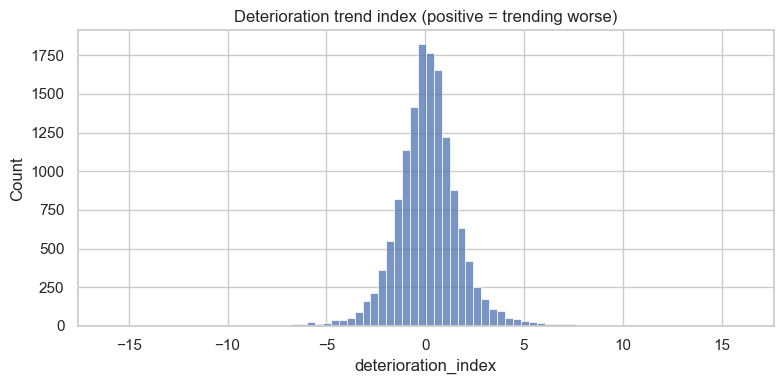

In [12]:
road_feats['trend_vv']   = z_robust(road_feats['vv_slope_year'])
road_feats['trend_bsi']  = z_robust(road_feats['bsi_slope_year'])
road_feats['trend_ndvi'] = z_robust(road_feats['ndvi_slope_year'])

road_feats['deterioration_index'] = (
    1.0 * road_feats['trend_vv'] +
    0.5 * road_feats['trend_bsi'] +
    0.3 * road_feats['trend_ndvi']
)

print(road_feats['deterioration_index'].describe().round(3))

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(road_feats['deterioration_index'], bins=80, ax=ax)
ax.set_title('Deterioration trend index (positive = trending worse)')
plt.tight_layout()
plt.show()

## 6) Combine into 3-class condition label

`combined_score = condition_score − 0.5 × deterioration_index`. Lower trend penalty so a currently-good road that's slightly trending worse still ranks above a chronically-poor road that's stable. Thresholds at tercile boundaries — the population assumption is roughly balanced, swap to fixed thresholds if domain knowledge says otherwise.

Threshold q33: -0.951    q67: 0.566

Predicted distribution (%):
pred_condition
low     33.3
good    33.3
med     33.3
Name: proportion, dtype: float64


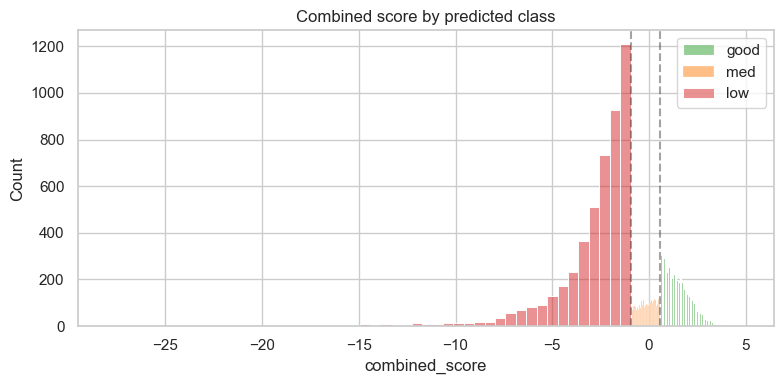

In [13]:
road_feats['combined_score'] = road_feats['condition_score'] - 0.5 * road_feats['deterioration_index']

q33, q67 = road_feats['combined_score'].quantile([1/3, 2/3])

def classify(x):
    if x >= q67:
        return 'good'
    elif x >= q33:
        return 'med'
    else:
        return 'low'

road_feats['pred_condition'] = road_feats['combined_score'].apply(classify)

print('Threshold q33:', round(q33, 3), '   q67:', round(q67, 3))
print('\nPredicted distribution (%):')
print(road_feats['pred_condition'].value_counts(normalize=True).mul(100).round(1))

fig, ax = plt.subplots(figsize=(8, 4))
for c, color in zip(['good', 'med', 'low'], ['#2ca02c', '#ff7f0e', '#d62728']):
    sns.histplot(road_feats.loc[road_feats['pred_condition'] == c, 'combined_score'],
                 bins=50, alpha=0.5, label=c, color=color, ax=ax)
ax.axvline(q33, color='k', ls='--', alpha=0.4)
ax.axvline(q67, color='k', ls='--', alpha=0.4)
ax.legend()
ax.set_title('Combined score by predicted class')
plt.tight_layout()
plt.show()

## 7) Supervised model on manual labels

Trains a calibrated Random Forest on the 2,096 visually-labelled roads. `class_weight='balanced'` compensates for the 77/19/4 label skew. `pred_confidence` from the Mapillary visual inspection acts as sample weights. `CalibratedClassifierCV` wraps the RF so it produces reliable class probabilities suitable for blending with the physics prior.

Out-of-fold (OOF) probabilities via 5-fold stratified CV give an unbiased view of supervised-model generalisation — used in §10 to evaluate the hybrid without data leakage.

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold, cross_val_predict
import warnings
warnings.filterwarnings('ignore')

# Load manual labels
manual_path = DATA_DIR / 'named_roads.xlsx'
manual_raw = pd.read_excel(manual_path, sheet_name='manual validation')
manual_raw['osm_id'] = manual_raw['osm_id'].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()
manual_raw['pred_confidence'] = pd.to_numeric(manual_raw['pred_confidence'], errors='coerce')

labelled = (
    manual_raw[manual_raw['pred_condition'].isin(['good', 'med', 'low'])]
    [['osm_id', 'pred_condition', 'pred_confidence']]
    .rename(columns={'pred_condition': 'manual_label'})
    .copy()
)
print(f'Labelled roads: {len(labelled)}')
print(labelled['manual_label'].value_counts())

# Raw satellite features + physics scores as inputs (physics scores give the RF the theory signal)
FEATURE_COLS = [
    'vv_mean', 'vv_std_temp', 'vh_mean', 'vvvh_mean', 'vvvh_std',
    'bsi_mean', 'bsi_std', 'ndvi_mean', 'ndvi_seasonal_amp', 'ndmi_mean',
    'vv_slope_year', 'bsi_slope_year', 'ndvi_slope_year',
    'condition_score', 'deterioration_index',
]

train_df = road_feats.merge(labelled, on='osm_id', how='inner').copy()
X_train = train_df[FEATURE_COLS].values
y_train = train_df['manual_label'].values
w_train = train_df['pred_confidence'].fillna(1.0).values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# OOF probabilities: each road predicted by a fold that never trained on it
# sklearn sorts classes alphabetically → ['good', 'low', 'med']
CLASSES = sorted(['good', 'low', 'med'])
oof_proba = cross_val_predict(
    RandomForestClassifier(
        n_estimators=300, class_weight='balanced',
        max_depth=10, min_samples_leaf=5, random_state=42,
    ),
    X_train, y_train, cv=skf, method='predict_proba',
)

# Final calibrated model trained on all labelled data
base_clf = RandomForestClassifier(
    n_estimators=500, class_weight='balanced',
    max_depth=10, min_samples_leaf=5, random_state=42,
)
clf = CalibratedClassifierCV(base_clf, cv=skf, method='isotonic')
clf.fit(X_train, y_train, sample_weight=w_train)
assert list(clf.classes_) == CLASSES, f'Unexpected class order: {clf.classes_}'

# Probabilities for all paved roads
X_all = road_feats[FEATURE_COLS].values
supervised_proba = clf.predict_proba(X_all)

print(f'\nClass order: {CLASSES}')
print('Supervised-only distribution across all roads (%):')
print(pd.Series([CLASSES[i] for i in supervised_proba.argmax(axis=1)])
      .value_counts(normalize=True).mul(100).round(1))

Labelled roads: 2096
manual_label
med     1623
low      394
good      79
Name: count, dtype: int64

Class order: ['good', 'low', 'med']
Supervised-only distribution across all roads (%):
med     99.2
low      0.5
good     0.3
Name: proportion, dtype: float64


## 8) Physics score → soft probabilities

Converts the scalar `combined_score` into a 3-class probability distribution via temperature-scaled softmax. `good` gets logit = +score, `low` = −score, `med` = 0 (neutral reference). Temperature controls sharpness: lower T → sharper distribution (physics more decisive), higher T → flatter (closer to uniform, supervised model has more influence everywhere).

In [15]:
from scipy.special import softmax as scipy_softmax

TEMPERATURE = 2.0  # tune alongside ALPHA in §9 — lower T sharpens physics prior

cs = road_feats['combined_score'].values
# Logit per class, columns ordered to match CLASSES: ['good', 'low', 'med']
class_logit = {'good': cs, 'low': -cs, 'med': np.zeros(len(cs))}
logits_physics = np.column_stack([class_logit[c] for c in CLASSES])
physics_proba = scipy_softmax(logits_physics / TEMPERATURE, axis=1)

print('Physics proba — mean per class:')
for i, c in enumerate(CLASSES):
    print(f'  {c}: {physics_proba[:, i].mean():.3f}')

print('\nPhysics-only distribution across all roads (%):')
print(pd.Series([CLASSES[i] for i in physics_proba.argmax(axis=1)])
      .value_counts(normalize=True).mul(100).round(1))

Physics proba — mean per class:
  good: 0.325
  low: 0.405
  med: 0.270

Physics-only distribution across all roads (%):
low     52.5
good    47.5
Name: proportion, dtype: float64


## 9) Hybrid blend: supervised + physics

`combined_proba = α × supervised_proba + (1−α) × physics_proba`. The α parameter controls how much to weight the data-driven signal versus the theoretical prior. Check the α sensitivity table in §10 and update `ALPHA` here accordingly.

Hybrid (α=0.5) distribution across all roads (%):
pred_hybrid
med     88.9
low     10.4
good     0.7
Name: proportion, dtype: float64


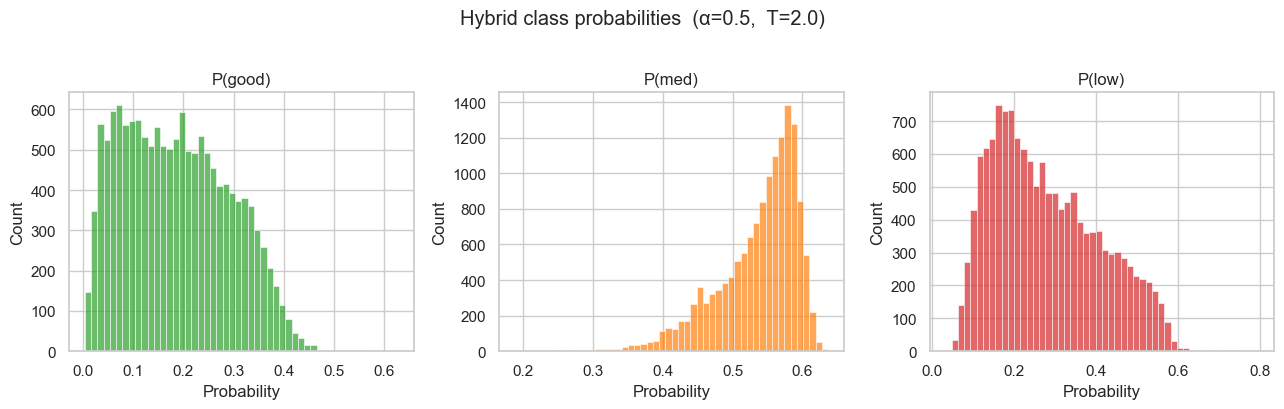

In [16]:
ALPHA = 0.5  # weight on supervised model (0 = physics only, 1 = supervised only)
             # run §10 first to find the best value, then update this and re-run §9 onwards

combined_proba = ALPHA * supervised_proba + (1 - ALPHA) * physics_proba

pred_indices = combined_proba.argmax(axis=1)
road_feats['pred_hybrid'] = [CLASSES[i] for i in pred_indices]
road_feats['hybrid_confidence'] = combined_proba.max(axis=1)

for i, cls in enumerate(CLASSES):
    road_feats[f'prob_{cls}'] = combined_proba[:, i]

print(f'Hybrid (α={ALPHA}) distribution across all roads (%):')
print(road_feats['pred_hybrid'].value_counts(normalize=True).mul(100).round(1))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, cls, color in zip(axes, ['good', 'med', 'low'], ['#2ca02c', '#ff7f0e', '#d62728']):
    ci = CLASSES.index(cls)
    sns.histplot(combined_proba[:, ci], bins=50, ax=ax, color=color, alpha=0.7)
    ax.set_title(f'P({cls})')
    ax.set_xlabel('Probability')
plt.suptitle(f'Hybrid class probabilities  (α={ALPHA},  T={TEMPERATURE})', y=1.02)
plt.tight_layout()
plt.show()

## 10) Evaluation against manual labels

Compares all three methods on the labelled roads using OOF probabilities (no data leakage). The α sensitivity table at the bottom shows the best blend weight — use it to update `ALPHA` in §9.

=== Physics score only ===
              precision    recall  f1-score   support

        good      0.031     0.494     0.058        79
         med      0.000     0.000     0.000      1591
         low      0.195     0.406     0.264       384

    accuracy                          0.095      2054
   macro avg      0.076     0.300     0.107      2054
weighted avg      0.038     0.095     0.052      2054

=== Supervised RF only (OOF) ===
              precision    recall  f1-score   support

        good      0.105     0.025     0.041        79
         med      0.790     0.916     0.848      1591
         low      0.347     0.172     0.230       384

    accuracy                          0.742      2054
   macro avg      0.414     0.371     0.373      2054
weighted avg      0.681     0.742     0.701      2054

=== Hybrid α=0.5 (OOF) ===
              precision    recall  f1-score   support

        good      0.024     0.063     0.035        79
         med      0.810     0.675     0.73

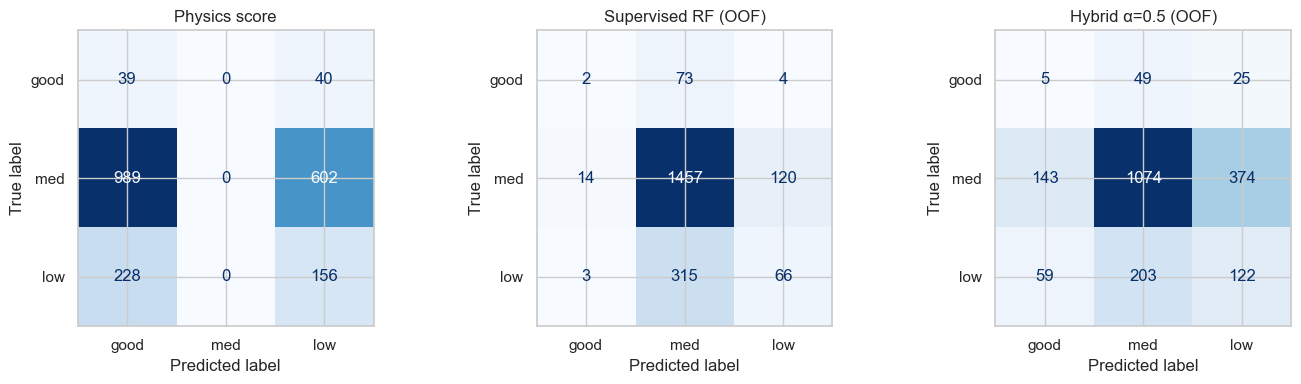


--- α sensitivity (balanced accuracy, OOF) ---
  α=0.0  balanced-acc=0.300
  α=0.2  balanced-acc=0.331
  α=0.3  balanced-acc=0.328
  α=0.4  balanced-acc=0.349
  α=0.5  balanced-acc=0.352  ← current ALPHA
  α=0.6  balanced-acc=0.375
  α=0.7  balanced-acc=0.375
  α=0.8  balanced-acc=0.379
  α=1.0  balanced-acc=0.371


In [17]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score

# Physics proba for labelled roads only (same TEMPERATURE as §8)
cs_train = train_df['combined_score'].values
class_logit_train = {'good': cs_train, 'low': -cs_train, 'med': np.zeros(len(cs_train))}
logits_train = np.column_stack([class_logit_train[c] for c in CLASSES])
physics_proba_train = scipy_softmax(logits_train / TEMPERATURE, axis=1)

# OOF hybrid blend
oof_hybrid_proba = ALPHA * oof_proba + (1 - ALPHA) * physics_proba_train

y_true = y_train.tolist()
label_order = ['good', 'med', 'low']

def preds_from_proba(proba):
    return [CLASSES[i] for i in proba.argmax(axis=1)]

print('=== Physics score only ===')
print(classification_report(y_true, preds_from_proba(physics_proba_train),
                             labels=label_order, digits=3, zero_division=0))

print('=== Supervised RF only (OOF) ===')
print(classification_report(y_true, preds_from_proba(oof_proba),
                             labels=label_order, digits=3, zero_division=0))

print(f'=== Hybrid α={ALPHA} (OOF) ===')
print(classification_report(y_true, preds_from_proba(oof_hybrid_proba),
                             labels=label_order, digits=3, zero_division=0))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, proba, title in zip(
    axes,
    [physics_proba_train, oof_proba, oof_hybrid_proba],
    ['Physics score', 'Supervised RF (OOF)', f'Hybrid α={ALPHA} (OOF)'],
):
    cm = confusion_matrix(y_true, preds_from_proba(proba), labels=label_order)
    ConfusionMatrixDisplay(cm, display_labels=label_order).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title)
plt.tight_layout()
plt.show()

print('\n--- α sensitivity (balanced accuracy, OOF) ---')
for alpha in [0.0, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0]:
    mixed = alpha * oof_proba + (1 - alpha) * physics_proba_train
    ba = balanced_accuracy_score(y_true, preds_from_proba(mixed))
    marker = '  ← current ALPHA' if alpha == ALPHA else ''
    print(f'  α={alpha:.1f}  balanced-acc={ba:.3f}{marker}')

## 11) Export predictions

In [ ]:
out_dir = ROOT / 'outputs'
out_dir.mkdir(exist_ok=True)
out_path = out_dir / 'layer2_new_predictions.csv'

export_cols = [
    'osm_id',
    'pred_hybrid',        # primary output: hybrid label
    'hybrid_confidence',  # max probability of winning class
    'prob_good', 'prob_low', 'prob_med',  # full probability distribution
    'pred_condition',     # physics-score-only label (for comparison)
    'combined_score', 'condition_score', 'deterioration_index',
    'vv_mean', 'vv_std_temp', 'vv_slope_year',
    'bsi_mean', 'bsi_slope_year',
    'ndvi_mean', 'ndvi_seasonal_amp', 'ndvi_slope_year',
]
export = road_feats[[c for c in export_cols if c in road_feats.columns]].copy()
export.to_csv(out_path, index=False)

print(f'Wrote {len(export)} predictions to {out_path}')
print('\nFinal hybrid class distribution:')
print(export['pred_hybrid'].value_counts())

## Notes & next steps

**Tuning α and T:** The α sensitivity table in §10 shows which blend weight gives the best balanced accuracy on the labelled set. If `good` recall is still poor (expected — only 79 labelled good roads), try α ∈ [0.3, 0.5] so the physics score has more influence on the sparse class. Lower T sharpens the physics prior; useful if the combined_score is a reliable discriminator.

**Class imbalance:** 77% `med`, 19% `low`, 4% `good` in the manual labels. `class_weight='balanced'` handles this in training. Adding even 50 more confirmed `good` roads would substantially improve that boundary — each `good` label is worth ~15× a `med` label at the current ratio.

**Layer 1 + Layer 2 integration:** This notebook uses OSM-tagged paved roads (~14k). Production path: take Layer 1 predicted-paved roads → apply hybrid scoring. Unpaved → `high` risk by policy rule.

**Calibrating against IRI:** With IRI survey data (Ghana Highway Authority, World Bank ROCKS), fit `IRI ~ combined_score + vv_mean + vv_slope_year` to convert the ordinal label into a calibrated roughness estimate and set non-equal class thresholds from real pavement condition intervals.